Loading and Viewing the Australia GeoDataframe
----------------------------------------------
1. Load and plot the data using `geopadas`.
2. Merge some regions into the `Eastern and SouthEastern Australia`.
3. Save the new GeoFrame merged Australian map into a new file.

In [1]:
import geopandas as gpd

gdf = gpd.read_file("../data/gadm41_AUS_1.json")

gdf.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,AUS.1_1,AUS,Australia,AshmoreandCartierIslands,NA,NA,Territory,Territory,12,AU.AS,NA,"MULTIPOLYGON (((123.5554 -12.5318, 123.5534 -1..."
1,AUS.2_1,AUS,Australia,AustralianCapitalTerritory,NA,NA,Territory,Territory,8,AU.AC,AU-ACT,"MULTIPOLYGON (((149.2007 -35.2054, 149.2059 -3..."
2,AUS.3_1,AUS,Australia,CoralSeaIslandsTerritory,NA,NA,Territory,Territory,11,AU.CR,NA,"MULTIPOLYGON (((155.5367 -23.2524, 155.5384 -2..."
3,AUS.4_1,AUS,Australia,JervisBayTerritory,NA,NA,Territory,Territory,10,AU.JB,NA,"MULTIPOLYGON (((150.6945 -35.1847, 150.6936 -3..."
4,AUS.5_1,AUS,Australia,NewSouthWales,NA,NA,State,State,1,AU.NS,AU-NSW,"MULTIPOLYGON (((152.0938 -32.7914, 152.0946 -3..."


<Axes: >

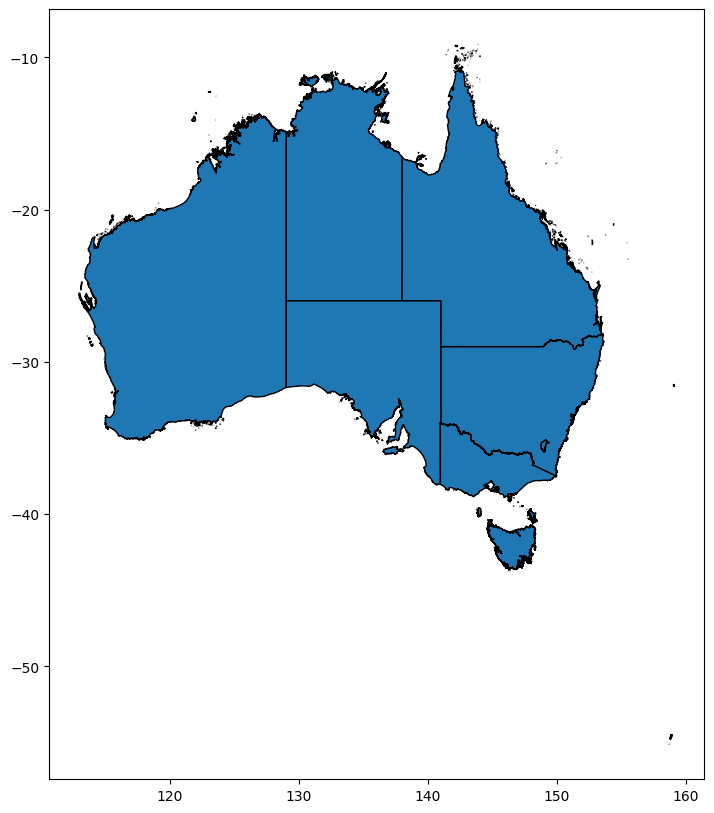

In [2]:
# Plotting the original map with all Australia's regions
gdf.plot(figsize=(10,10), edgecolor='black')

In [3]:
# Region filtering for the 4 regions first, then merge the rest into 1 to make 5 total.
regions = ["AUS.11_1", "AUS.6_1", "AUS.8_1", "AUS.7_1"]

# Merging the fifth region
merge_ids = ["AUS.5_1", "AUS.10_1", "AUS.9_1", "AUS.2_1"]
region5_gdf = gdf[gdf['GID_1'].isin(merge_ids)].copy()

region5_gdf.head()


,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
1,AUS.2_1,AUS,Australia,AustralianCapitalTerritory,NA,NA,Territory,Territory,8,AU.AC,AU-ACT,"MULTIPOLYGON (((149.2007 -35.2054, 149.2059 -3..."
4,AUS.5_1,AUS,Australia,NewSouthWales,NA,NA,State,State,1,AU.NS,AU-NSW,"MULTIPOLYGON (((152.0938 -32.7914, 152.0946 -3..."
8,AUS.9_1,AUS,Australia,Tasmania,NA,NA,State,State,6,AU.TS,AU-TAS,"MULTIPOLYGON (((145.61882 -43.0149, 145.617 -4..."
9,AUS.10_1,AUS,Australia,Victoria,NA,NA,State,State,2,AU.VI,AU-VIC,"MULTIPOLYGON (((146.2962 -39.157, 146.2949 -39..."


In [4]:
# Dissolving the geometries of region 5 into 1.
region5_gdf = region5_gdf.dissolve()
# Updating the metadata
region5_gdf['GID_1'] = 'AUS.5_1'
region5_gdf['NAME_1'] = "Eastern and Southern Australia"
region5_gdf.head()

,geometry,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1
0,"MULTIPOLYGON (((143.8751 -40.1166, 143.875 -40...",AUS.5_1,AUS,Australia,Eastern and Southern Australia,NA,NA,Territory,Territory,8,AU.AC,AU-ACT


In [5]:
# Merging the 4 regions and the new region 5 into a new GeoDataFrame
remaining_gdf = gdf[gdf['GID_1'].isin(regions)]
aus_gdf = gpd.pd.concat([remaining_gdf, region5_gdf], ignore_index=True)
aus_gdf.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,AUS.6_1,AUS,Australia,NorthernTerritory,NA,NA,Territory,Territory,7,AU.NT,AU-NT,"MULTIPOLYGON (((137.0685 -15.8631, 137.0677 -1..."
1,AUS.7_1,AUS,Australia,Queensland,NA,NA,State,State,3,AU.QL,AU-QLD,"MULTIPOLYGON (((151.0748 -23.4711, 151.0722 -2..."
2,AUS.8_1,AUS,Australia,SouthAustralia,NA,NA,State,State,4,AU.SA,AU-SA,"MULTIPOLYGON (((140.661 -38.0624, 140.6605 -38..."
3,AUS.11_1,AUS,Australia,WesternAustralia,NA,NA,State,State,5,AU.WA,AU-WA,"MULTIPOLYGON (((113.1189 -25.0287, 113.1173 -2..."
4,AUS.5_1,AUS,Australia,Eastern and Southern Australia,NA,NA,Territory,Territory,8,AU.AC,AU-ACT,"MULTIPOLYGON (((143.8751 -40.1166, 143.875 -40..."


<Axes: >

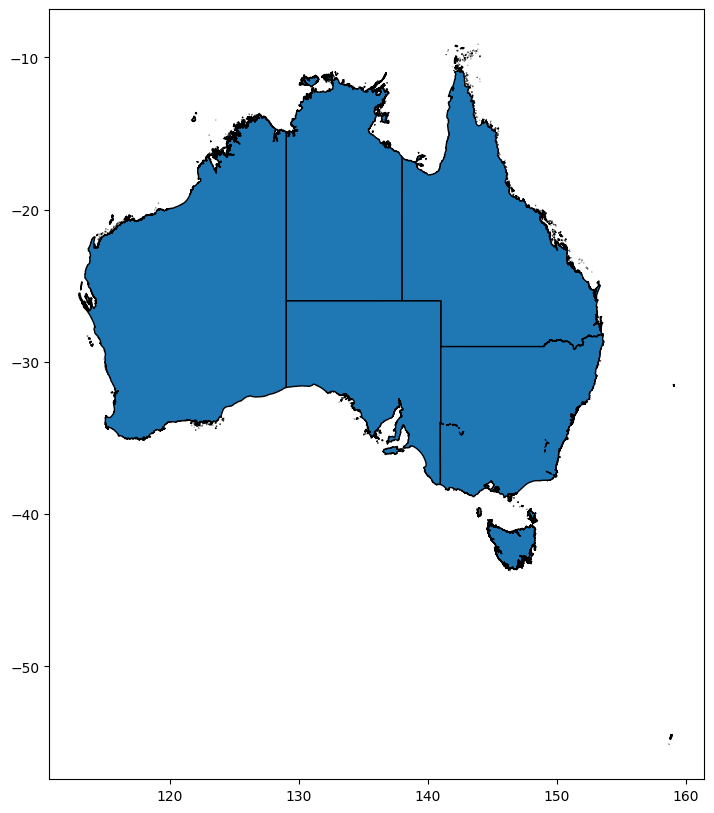

In [6]:
aus_gdf.plot(figsize=(10,10), edgecolor='black')

In [7]:
# Saving the new cleand GeoDataFrame to a new file
aus_gdf.to_file("../data/aus_clean.json", driver='GeoJSON')